# Obtaining & exploring dataset

In [1]:
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings("ignore")
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from pts.model.tempflow import TempFlowEstimator

from pts.model.tempflow import TempFlowEstimator_mod
from pts.model.tempflow import TempFlowEstimator_nRelu

from pts import Trainer
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt

In [2]:
dataset = get_dataset("solar_nips", regenerate=False)
#dataset = get_dataset("traffic_nips", regenerate=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
#np.random.seed(12345)
#torch.manual_seed(12345)
#torch.cuda.manual_seed(12345)

In [4]:

''' Para train y val
from gluonts.dataset.field_names import FieldName
import pandas as pd 
from gluonts.dataset.common import ListDataset

def split_train_validation_multivariate(dataset, val_ratio=0.2):
    train_list = list(dataset)
    train_data = []
    val_data = []
    for entry in train_list:
        target = entry[FieldName.TARGET]
        #train_len = int(target.shape[0] * (1 - val_ratio))
        train_target = target[:-24]
        val_target = target[-24:]
        
        train_data.append(
            {k: v for k, v in entry.items() if k != FieldName.TARGET}
        )
        train_data[-1][FieldName.TARGET] = train_target
        
        val_data.append(
            {k: v for k, v in entry.items() if k != FieldName.TARGET}
        )
        val_data[-1][FieldName.TARGET] = val_target
        val_data[-1][FieldName.START] = entry[FieldName.START] + pd.Timedelta(hours=train_target.shape[0])
        
    return ListDataset(train_data, freq="H"), ListDataset(val_data, freq="H")

train_ds, val_ds = split_train_validation_multivariate(dataset.train)

'''



' Para train y val\nfrom gluonts.dataset.field_names import FieldName\nimport pandas as pd \nfrom gluonts.dataset.common import ListDataset\n\ndef split_train_validation_multivariate(dataset, val_ratio=0.2):\n    train_list = list(dataset)\n    train_data = []\n    val_data = []\n    for entry in train_list:\n        target = entry[FieldName.TARGET]\n        #train_len = int(target.shape[0] * (1 - val_ratio))\n        train_target = target[:-24]\n        val_target = target[-24:]\n        \n        train_data.append(\n            {k: v for k, v in entry.items() if k != FieldName.TARGET}\n        )\n        train_data[-1][FieldName.TARGET] = train_target\n        \n        val_data.append(\n            {k: v for k, v in entry.items() if k != FieldName.TARGET}\n        )\n        val_data[-1][FieldName.TARGET] = val_target\n        val_data[-1][FieldName.START] = entry[FieldName.START] + pd.Timedelta(hours=train_target.shape[0])\n        \n    return ListDataset(train_data, freq="H"), Li


## Prepare dataset

In [3]:
train_grouper = MultivariateGrouper(max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

test_grouper = MultivariateGrouper(num_test_dates=int(len(dataset.test)/len(dataset.train)),
                                   max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

#dataset_train = train_grouper(train_ds)
#dataset_val = train_grouper(val_ds)

## Evaluator

In [4]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

## Modelo

## Traffic

In [9]:
#traffic
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)

In [10]:
estimator_mod = TempFlowEstimator_mod(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)

## Solar nips

In [5]:
estimator_mod = TempFlowEstimator_mod(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=20,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [6]:
predictor_mod = estimator_mod.train(dataset_train, prefetch_factor = None)

100%|██████████| 99/99 [00:15<00:00,  6.29it/s, epoch=20/20, avg_loss=59.2]


# Samples

In [14]:
forecast_it_mod, ts_it = make_evaluation_predictions(dataset=dataset_test,
                                             predictor=predictor_mod,
                                             num_samples=100,
                                             a_scalar = 0.8)
forecasts_mod = list(forecast_it_mod)
targets = list(ts_it)

agg_metric_mod, _ = evaluator(targets, forecasts_mod, num_series=len(dataset_test))

input: ['target_dimension_indicator', 'past_time_feat', 'past_target_cdf', 'past_observed_values', 'past_is_pad', 'future_time_feat']
repeated shape: torch.Size([700, 216, 137])


Running evaluation: 7it [00:00, 149.32it/s]
Running evaluation: 7it [00:00, 157.67it/s]
Running evaluation: 7it [00:00, 161.02it/s]
Running evaluation: 7it [00:00, 158.41it/s]
Running evaluation: 7it [00:00, 154.73it/s]
Running evaluation: 7it [00:00, 156.60it/s]
Running evaluation: 7it [00:00, 157.74it/s]
Running evaluation: 7it [00:00, 152.66it/s]
Running evaluation: 7it [00:00, 154.21it/s]
Running evaluation: 7it [00:00, 156.59it/s]
Running evaluation: 7it [00:00, 156.67it/s]
Running evaluation: 7it [00:00, 155.94it/s]
Running evaluation: 7it [00:00, 157.17it/s]
Running evaluation: 7it [00:00, 148.08it/s]
Running evaluation: 7it [00:00, 161.46it/s]
Running evaluation: 7it [00:00, 158.82it/s]
Running evaluation: 7it [00:00, 155.40it/s]
Running evaluation: 7it [00:00, 155.13it/s]
Running evaluation: 7it [00:00, 156.98it/s]
Running evaluation: 7it [00:00, 149.94it/s]
Running evaluation: 7it [00:00, 146.99it/s]
Running evaluation: 7it [00:00, 153.75it/s]
Running evaluation: 7it [00:00, 

In [15]:
def plot(target, forecast, prediction_length, prediction_intervals=(50.0, 90.0), color='g', fname=None):
    label_prefix = ""
    rows = 5
    cols = 5
    fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
    axx = axs.ravel()
    seq_len, target_dim = target.shape

    ps = [50.0] + [
            50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
        ]

    percentiles_sorted = sorted(set(ps))

    def alpha_for_percentile(p):
        return (p / 100.0) ** 0.3

    for dim in range(0, min(rows * cols, target_dim)):
        ax = axx[dim]

        target[-2 * prediction_length :][dim].plot(ax=ax)

        ps_data = [forecast.quantile(p / 100.0)[:,dim] for p in percentiles_sorted]
        i_p50 = len(percentiles_sorted) // 2

        p50_data = ps_data[i_p50]
        p50_series = pd.Series(data=p50_data, index=forecast.index)
        p50_series.plot(color=color, ls="-", label=f"{label_prefix}median", ax=ax)

        for i in range(len(percentiles_sorted) // 2):
            ptile = percentiles_sorted[i]
            alpha = alpha_for_percentile(ptile)
            ax.fill_between(
                forecast.index,
                ps_data[i],
                ps_data[-i - 1],
                facecolor=color,
                alpha=alpha,
                interpolate=True,
            )
            # Hack to create labels for the error intervals.
            # Doesn't actually plot anything, because we only pass a single data point
            pd.Series(data=p50_data[:1], index=forecast.index[:1]).plot(
                color=color,
                alpha=alpha,
                linewidth=10,
                label=f"{label_prefix}{100 - ptile * 2}%",
                ax=ax,
            )

    legend = ["observations", "median prediction"] + [f"{k}% prediction interval" for k in prediction_intervals][::-1]
    axx[0].legend(legend, loc="upper left")

    if fname is not None:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)


import matplotlib.pyplot as plt


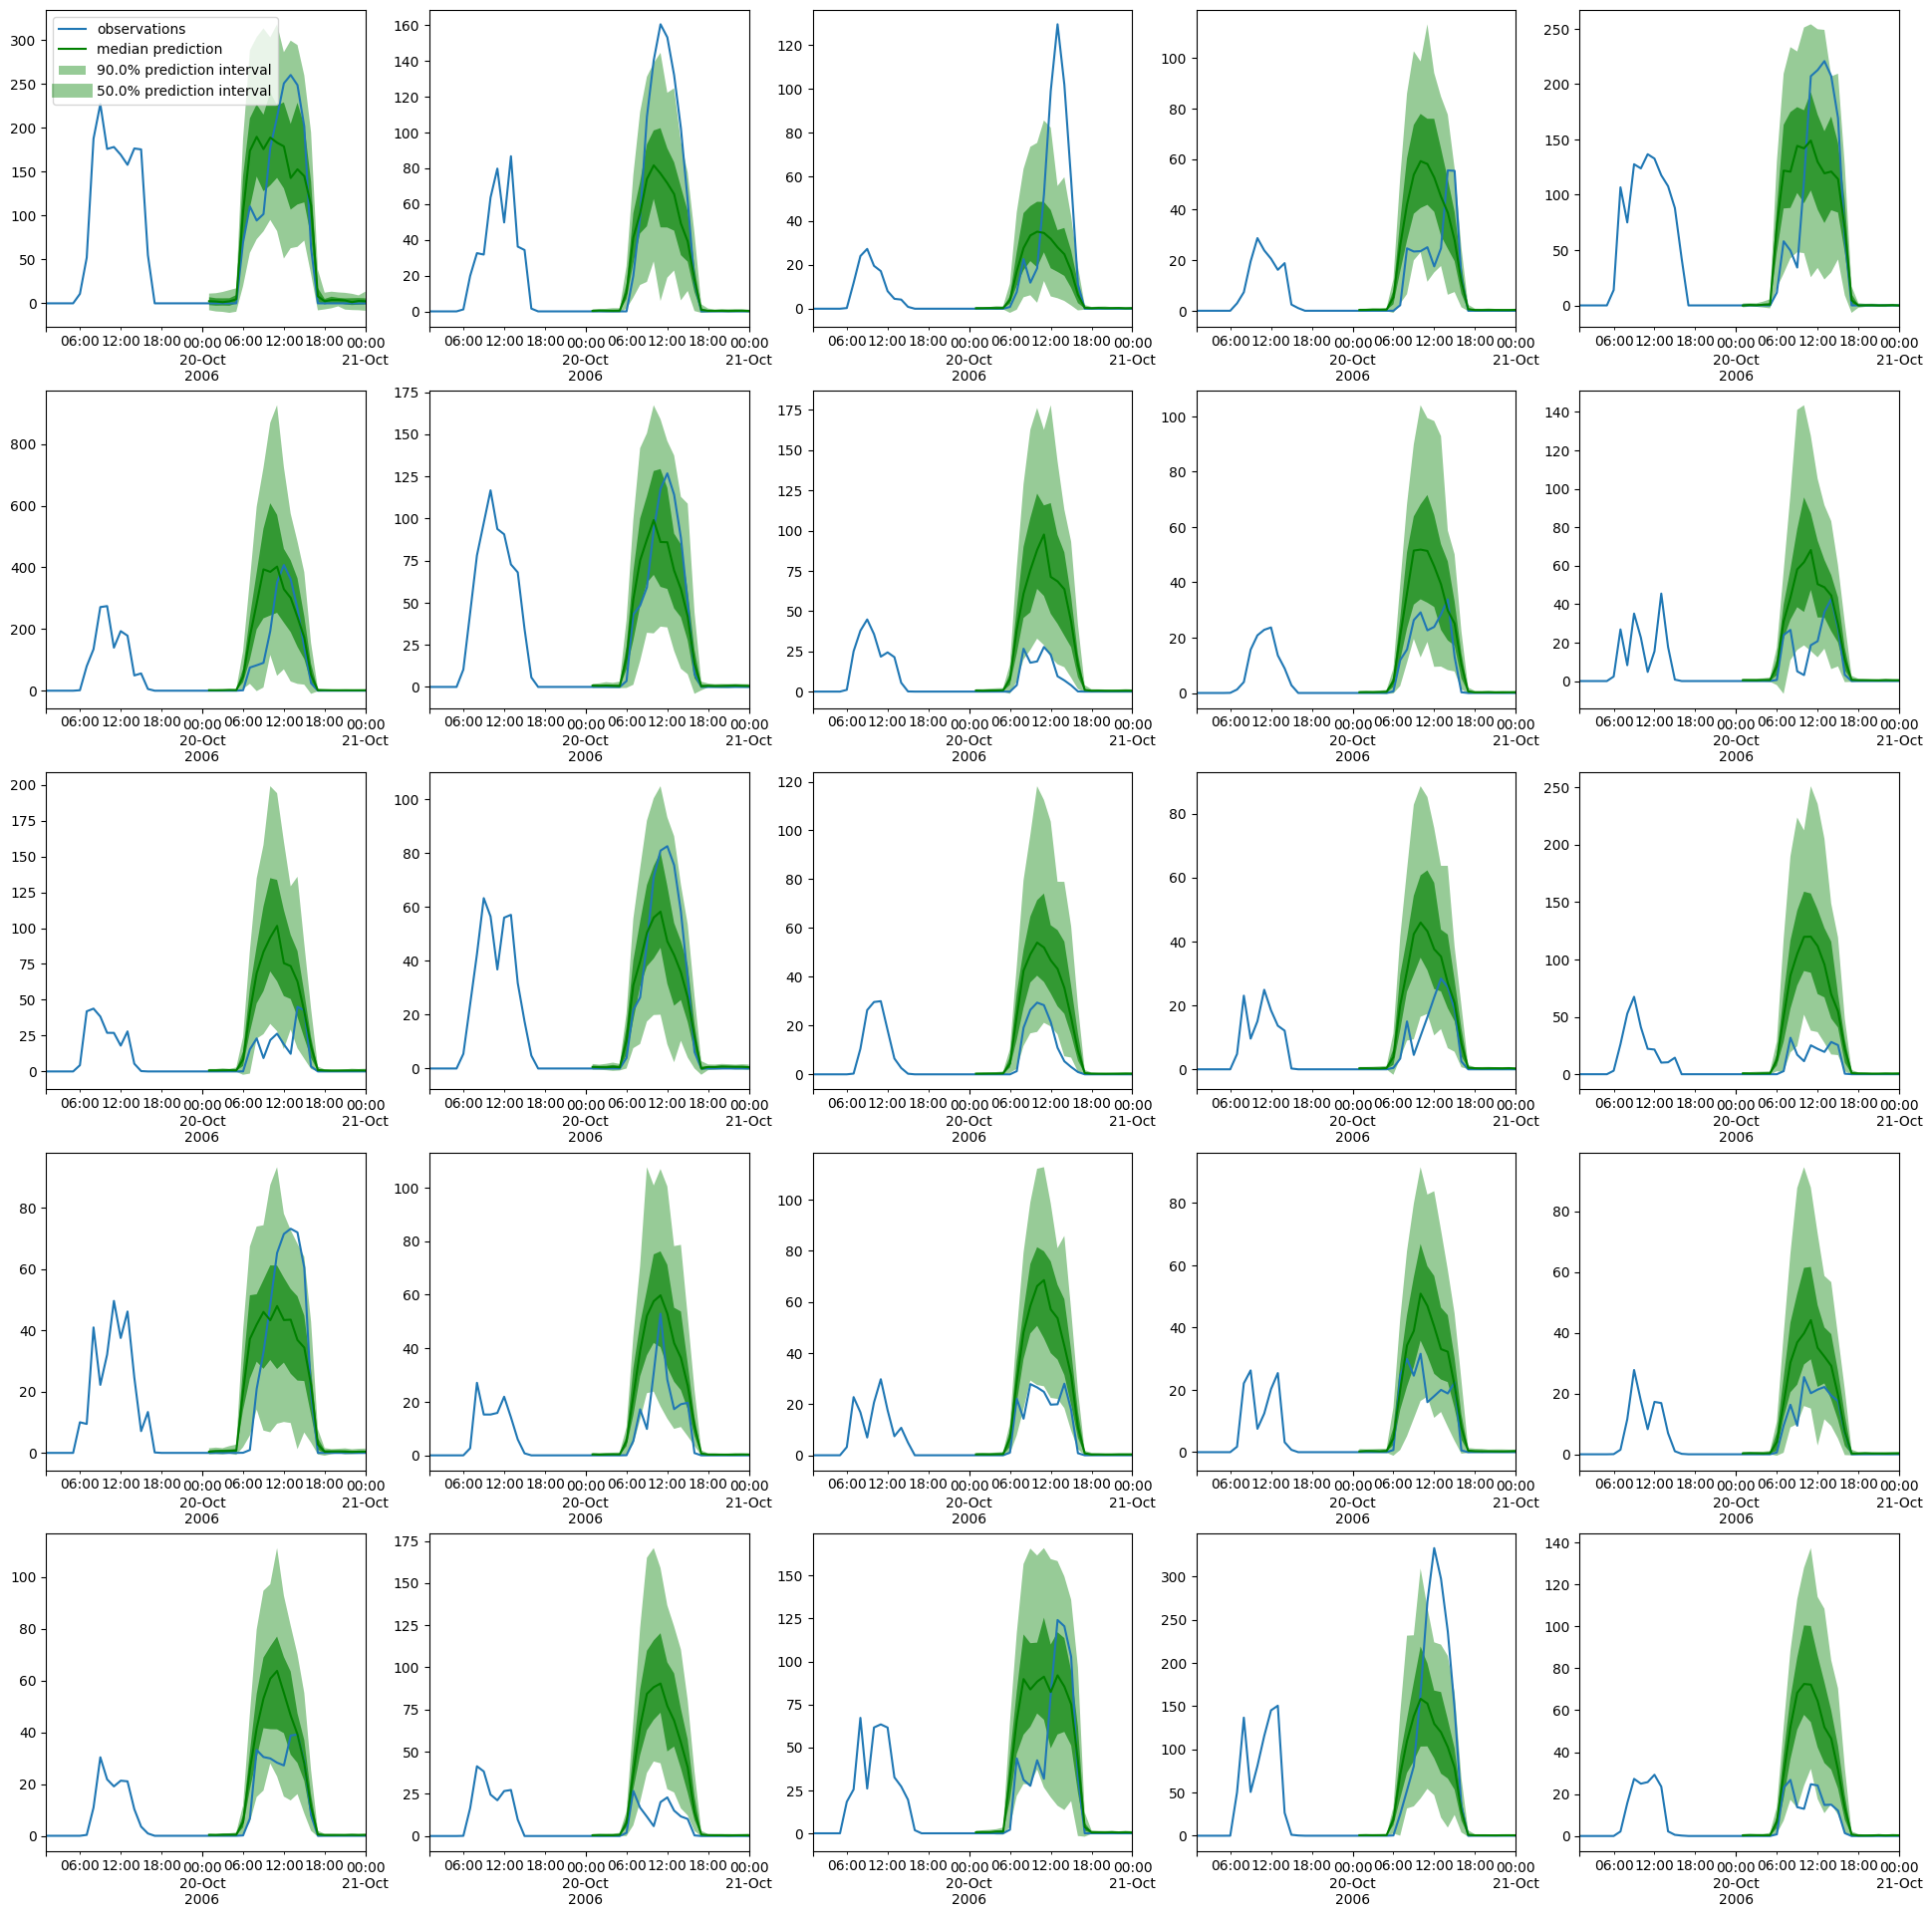

In [16]:
plot(
    target=targets[0],
    forecast=forecasts_mod[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

# Metrics

In [17]:
#log sigmoid
print("CRPS: {}".format(agg_metric_mod['mean_wQuantileLoss']))
print("ND: {}".format(agg_metric_mod['ND']))
print("NRMSE: {}".format(agg_metric_mod['NRMSE']))
print("MSE: {}".format(agg_metric_mod['MSE']))

print("CRPS-Sum: {}".format(agg_metric_mod['m_sum_mean_wQuantileLoss']))
print("ND-Sum: {}".format(agg_metric_mod['m_sum_ND']))
print("NRMSE-Sum: {}".format(agg_metric_mod['m_sum_NRMSE']))
print("MSE-Sum: {}".format(agg_metric_mod['m_sum_MSE']))

CRPS: 0.3942352104038779
ND: 0.524810758565559
NRMSE: 1.05910876813678
MSE: 1064.0423517489044
CRPS-Sum: 0.314524242780659
ND-Sum: 0.4026760718691106
NRMSE-Sum: 0.739372507818633
MSE-Sum: 9732973.464285715


# Uso de muestras

In [18]:
def plot_with_threshold(serie, threshold):
    # Plotear la serie de tiempo
    plt.figure(figsize=(10, 5))
    plt.plot(serie, label='Train')
    #plt.plot(full_test, label ='Test')

    # Agregar una línea recta al gráfico
    # Por ejemplo, una línea horizontal en y=3
    plt.axhline(y=threshold, color='r', linestyle='--', label='threshold')

    # Configurar etiquetas y leyenda
    plt.xlabel('Fecha')
    plt.ylabel('Valor')
    plt.legend()

    # Mostrar el gráfico
    plt.show()



In [20]:
prediction_length = predictor_mod.prediction_length
lead_time = predictor_mod.lead_time
freq = predictor_mod.freq

muestras = forecasts_mod[0].samples
samples = muestras[:,:,5] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][5].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][5].index


train = targets[0][:-prediction_length ][5] #Sin las ultimas 48 horas de test.
test = targets[0][-prediction_length:][5] # SoLO ULTIMAS 24

## MRL

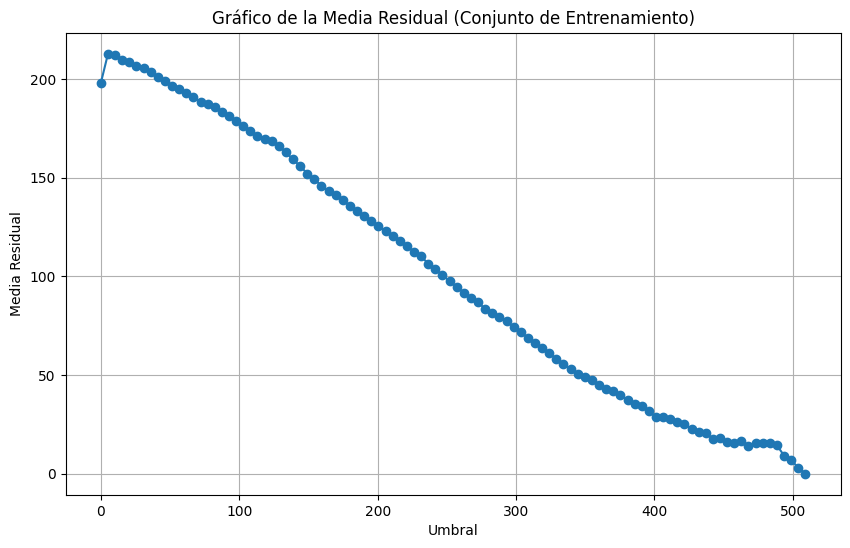

In [72]:
def mean_residual_life(data, thresholds):
    mrl = []
    for u in thresholds:
        excesses = data[data > u] - u
        if len(excesses) > 0:
            mrl.append(np.mean(excesses))
        else:
            mrl.append(0)
    return mrl

# Definir umbrales
thresholds = np.linspace(train.min(), train.max(), 100)

# Calcular la media residual para cada umbral
mrl_values = mean_residual_life(train, thresholds)

# Graficar la media residual
plt.figure(figsize=(10, 6))
plt.plot(thresholds, mrl_values, marker='o')
plt.xlabel('Umbral')
plt.ylabel('Media Residual')
plt.title('Gráfico de la Media Residual (Conjunto de Entrenamiento)')
plt.grid(True)
plt.show()


In [73]:
# Selección automática del umbral (por ejemplo, donde la media residual se nivela)
# Aquí se elige el umbral donde el incremento en la media residual es más pequeño
diffs = np.diff(mrl_values)
selected_threshold_index = np.argmin(diffs) + 1
selected_threshold = thresholds[selected_threshold_index]

print(f"Umbral seleccionado: {selected_threshold}")


Umbral seleccionado: 493.62423058712125


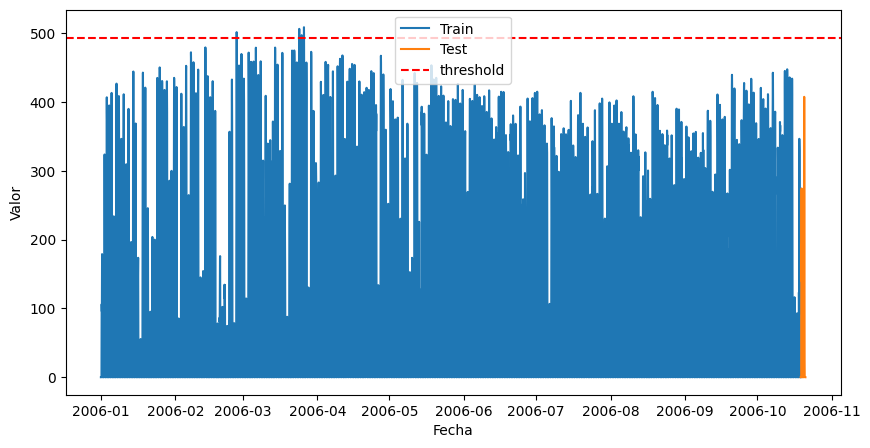

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(train, label='Train')
plt.plot(full_test, label ='Test')

# Agregar una línea recta al gráfico
# Por ejemplo, una línea horizontal en y=3
plt.axhline(y=selected_threshold, color='r', linestyle='--', label='threshold')

# Configurar etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()

# Mostrar el gráfico
plt.show()

## q75 + rango_iqr

In [ ]:
def rango_iqr(serie, k, full_test, return_thresholds = False): # tipicamente k = 1.5, 3
    q25, q75 = np.percentile(serie, 25), np.percentile(serie, 75)
    iqr = q75 - q25
    # Linea de corte.
    cut_off = iqr * k
    #lower, upper = q25 - cut_off, q75 + cut_off
    upper = q75 + cut_off

    plt.figure(figsize=(10, 5))
    plt.plot(serie, label='Train')
    plt.plot(full_test, label ='Test')

    plt.axhline(y=upper, color='r', linestyle='--', label='threshold')

    plt.xlabel('Fecha')
    plt.ylabel('Valor')
    plt.legend()

    # Mostrar el gráfico
    plt.show()

    return upper

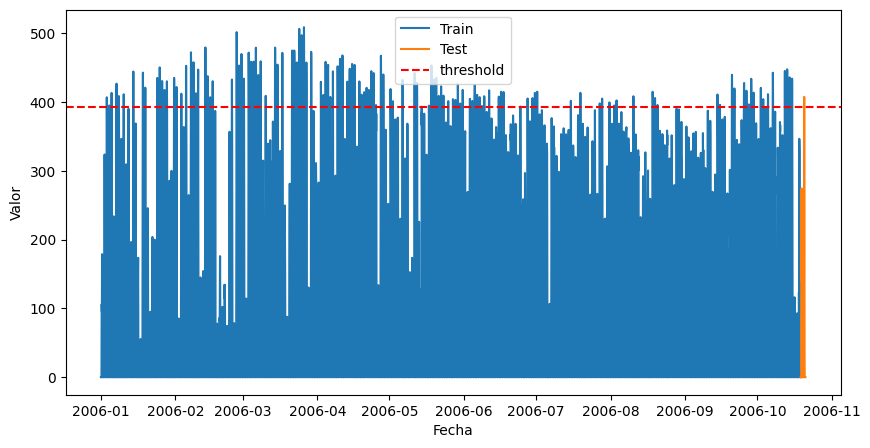

In [77]:
upper = rango_iqr(train,k = 1, full_test=full_test) # Threshold.

# Cuartiles

## Funciones para plotear

In [116]:
def plot_with_threshold(serie, threshold):

    plt.figure(figsize=(10, 5))
    plt.plot(serie, label='Train', color = 'blue')

    plt.axhline(y=threshold, color='r', linestyle='--', label='threshold')

    plt.xlabel('Fecha')
    plt.ylabel('Valor')
    plt.legend()


    plt.show()

def plot_samples_with_threshold(muestras, threshold):
    #para plotear las muestras y el threshold.

    plt.figure(figsize=(12, 8))

    for i in range(muestras.shape[0]):
        plt.plot(muestras[i], color='green', alpha=0.3)

    plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold y={threshold}')

    plt.xlabel('Hora')
    plt.ylabel('Valor')
    plt.title('muestras y threshold')
    plt.legend()
    
    plt.show()

def plot_mean_POT(muestras, test, threshold):
    # POT (peak over threshold)
    samples_mean = np.mean(muestras, axis=0)
    samples_df = pd.Series(samples_mean, index=test.index)

    samples_over_threshold = samples_df > threshold
    test_over_threshold = test > threshold

    plt.figure(figsize=(12, 6))
    
    plt.plot(samples_df, label='Promedio de muestras', linestyle='--', color='green')

    plt.scatter(samples_df.index[samples_over_threshold], samples_df[samples_over_threshold], color='green', marker='o') #marca de peak

    plt.plot(test, label='Test', linestyle='-', color='blue')
    plt.scatter(test.index[test_over_threshold], test[test_over_threshold], color='blue', marker='o') #marca de peak

    plt.axhline(y=threshold, color='red', linestyle='-', label='Threshold')

    plt.xlabel('Hora')
    plt.ylabel('Valor')
    plt.title('Promedio de las muestras y conjunto test')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_porcentaje_POT(muestras, threshold):
    porcentaje_sobre_threshold = (muestras>threshold).mean(axis=0)*100
    

    plt.figure(figsize=(12, 6))
    plt.plot(range(24), porcentaje_sobre_threshold, linestyle='-', marker='o', color='green')
    
    plt.xlabel('Hora')
    plt.ylabel('%')
    plt.title('Porcentaje de muestras sobre el threshold')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_POT(muestras, test, threshold, cut_off):
    # Crear un DataFrame para muestras con el mismo índice que test
    samples_over_threshold = (muestras > threshold).mean(axis=0)  # Contar las muestras que superan el umbral por hora

    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test.values, label='Test', linestyle='-', color='blue') #grafico del test.

    peak_flag = False

    for hour, proporcion in enumerate(samples_over_threshold):
        if proporcion > cut_off:  # Verificar si más del 50% de las muestras superan el umbral
            if not peak_flag:
                plt.scatter(test.index[hour], test[hour], color='red', marker='o', s=50, label = 'Peak')
                peak_flag = True
            else:
                plt.scatter(test.index[hour], test[hour], color='red', marker='o', s=50)

    plt.axhline(y=threshold, color='red', linestyle='-', label='Threshold')
    
    plt.xlabel('Hora')
    plt.ylabel('Valor')
    plt.title('Peaks over threshold')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## q75

Max: 509.04998779296875
Min: 0.0
q75: 195.89999389648438


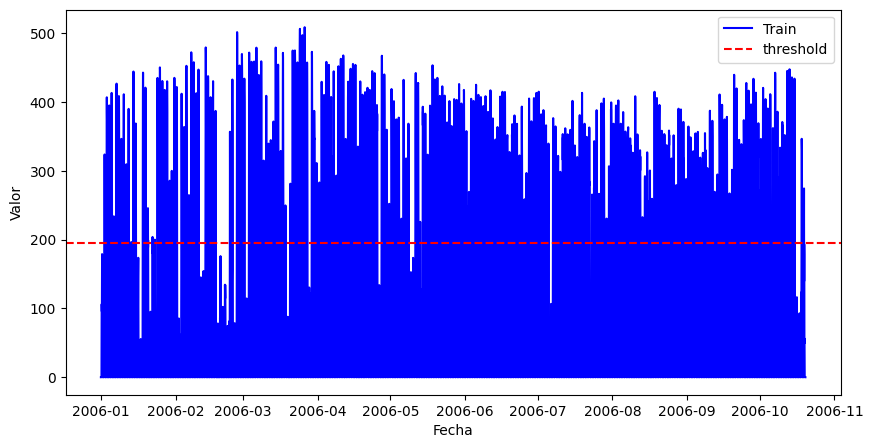

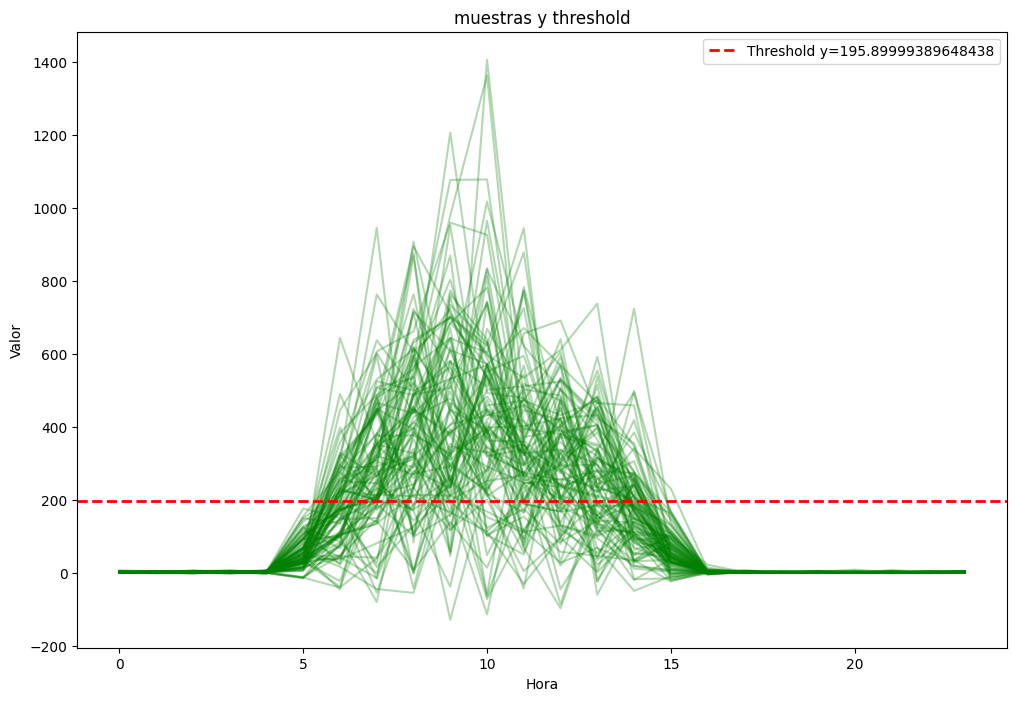

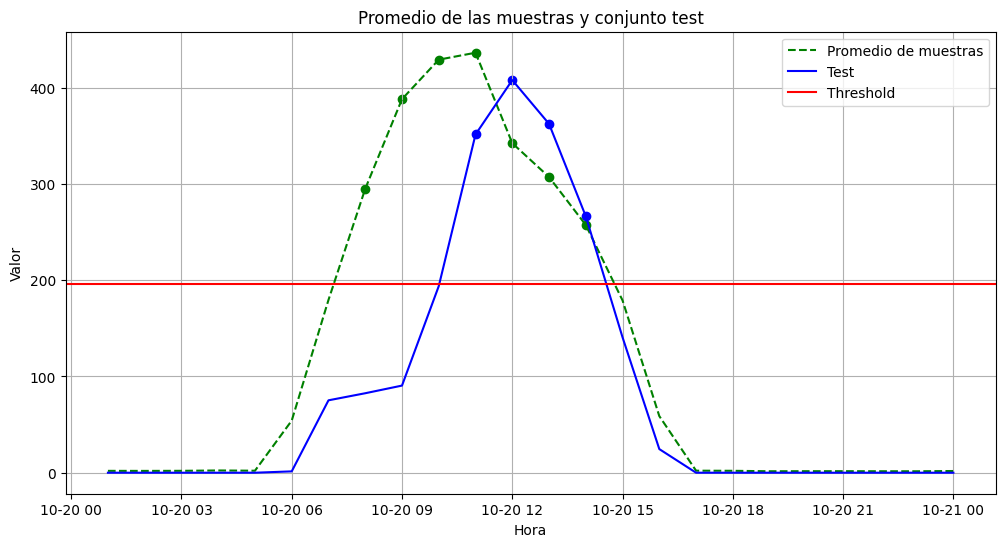

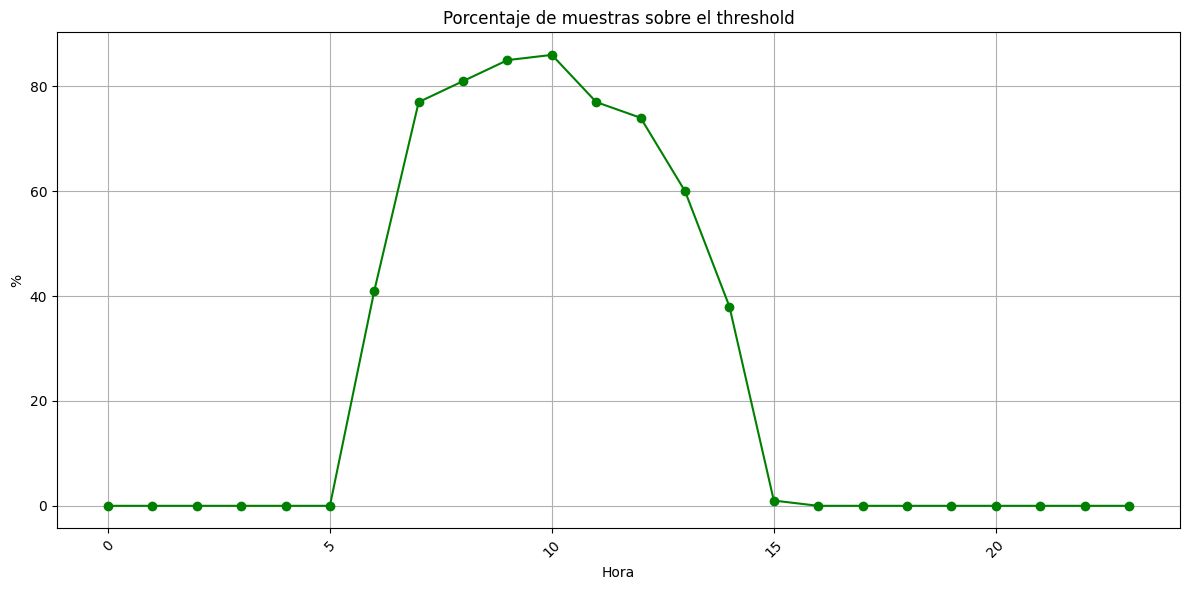

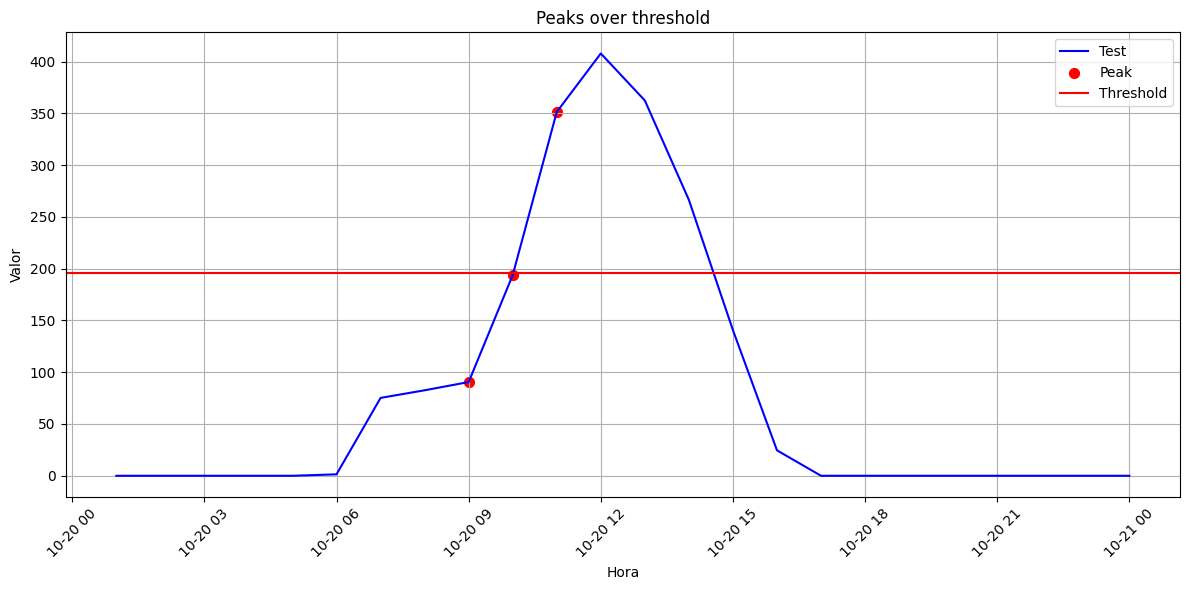

In [117]:
q75 = np.percentile(train, 75)
print(f"Max: {train.max()}\nMin: {train.min()}\nq75: {q75}")

plot_with_threshold(train, q75)
plot_samples_with_threshold(samples, q75)
plot_mean_POT(samples, test, q75)
plot_porcentaje_POT(samples, q75)
plot_POT(samples, test, q75, cut_off = 0.8)

## P80

Max: 509.04998779296875
Min: 0.0
p80: 250.4999938964845


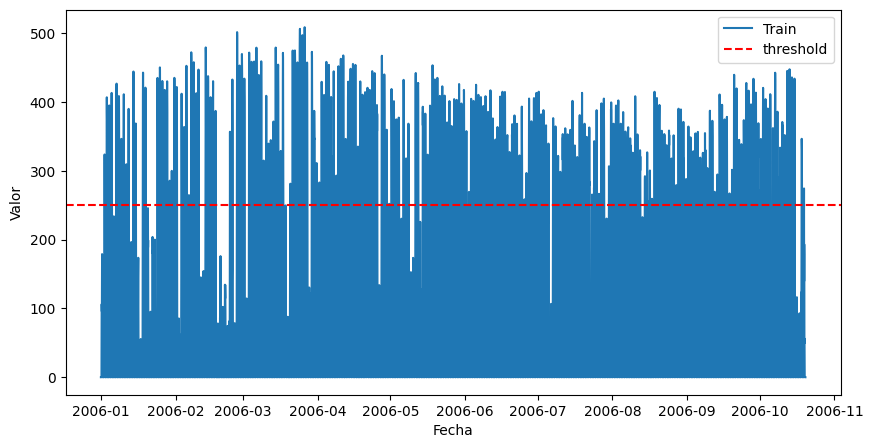

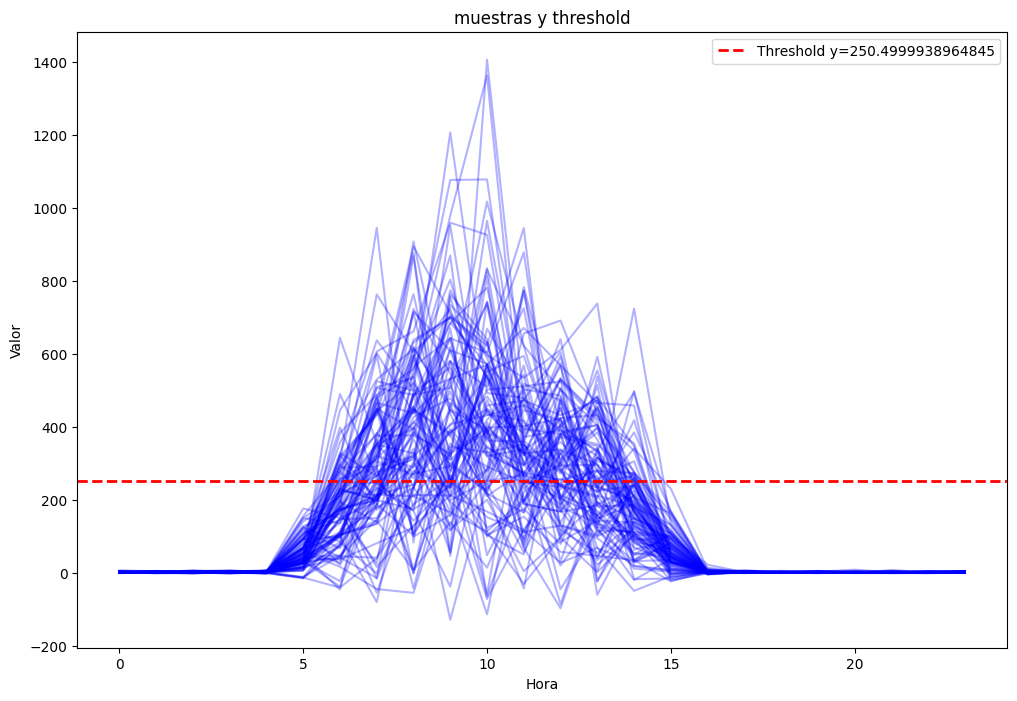

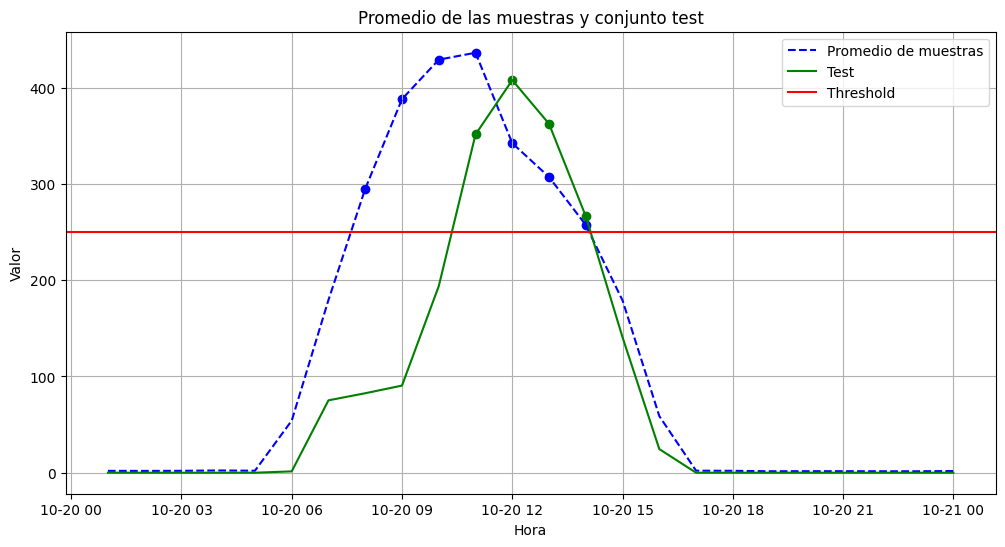

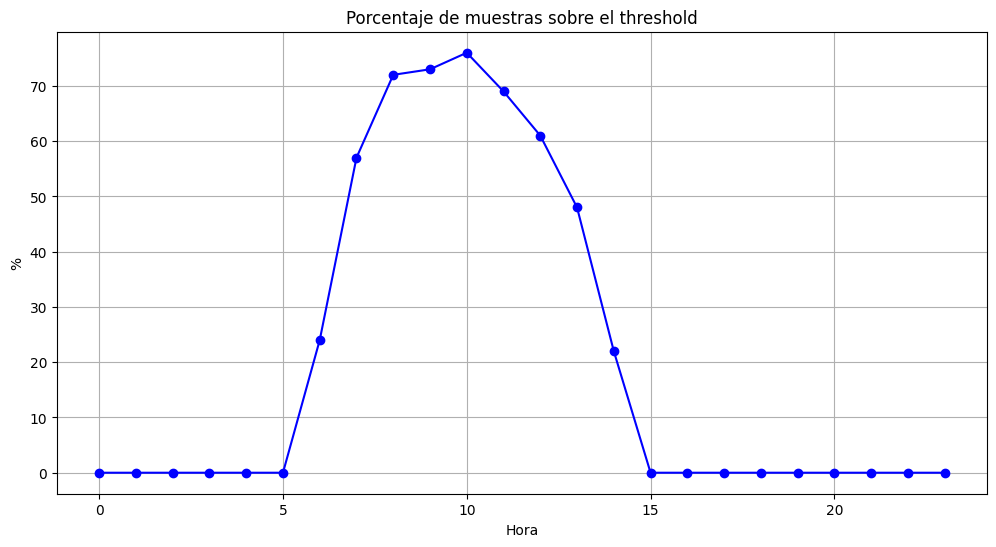

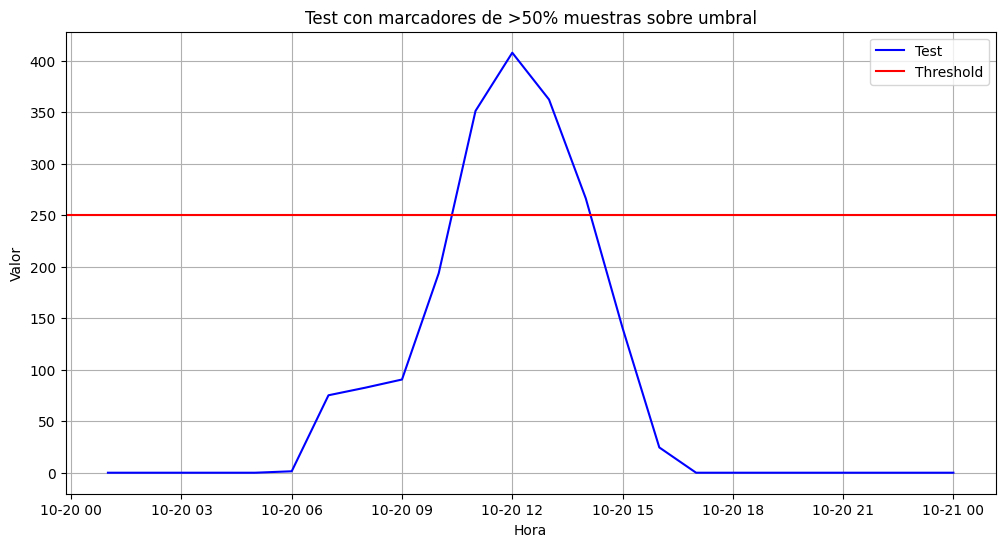

In [105]:
p80 = np.percentile(train, 80)
print(f"Max: {train.max()}\nMin: {train.min()}\np80: {p80}")

plot_with_threshold(train, p80)
plot_samples_with_threshold(samples, p80)
plot_mean_POT(samples, test, p80)
plot_porcentaje_POT(samples, p80)
plot_POT(samples, test, p80, cut_off = 0.8)

## P90

Max: 509.04998779296875
Min: 0.0
p90: 348.3700073242187


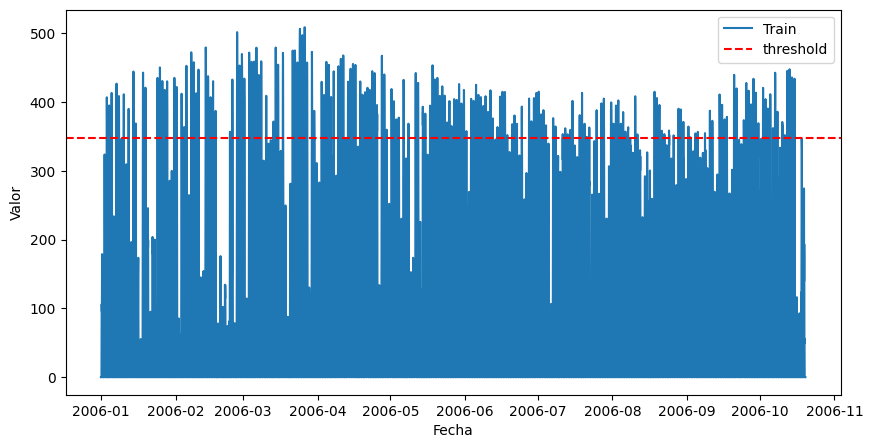

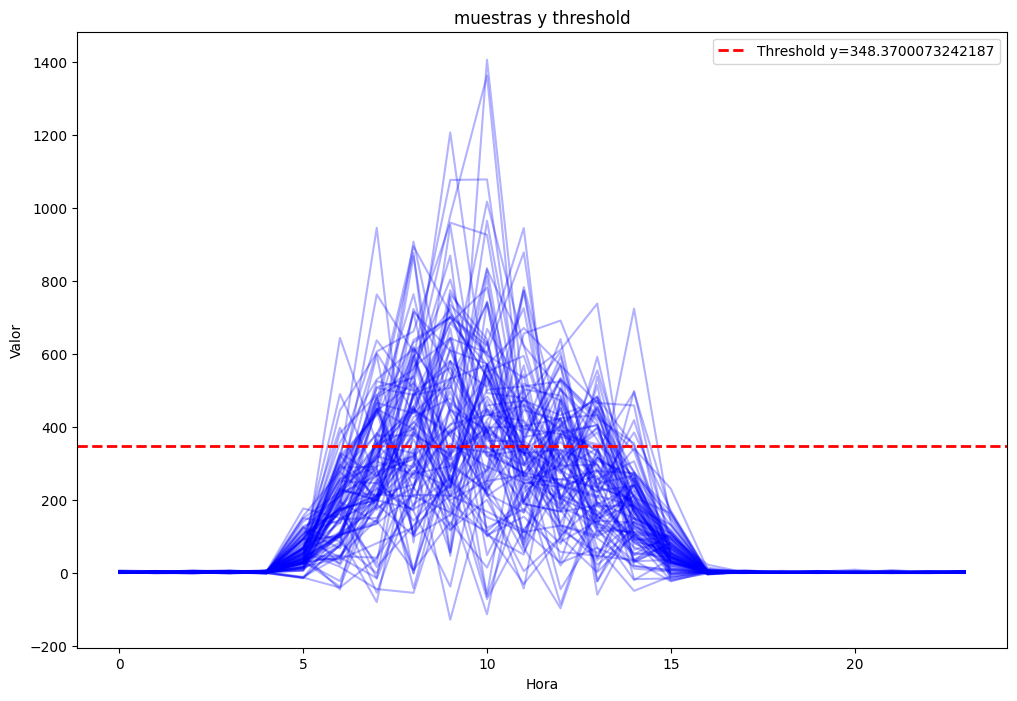

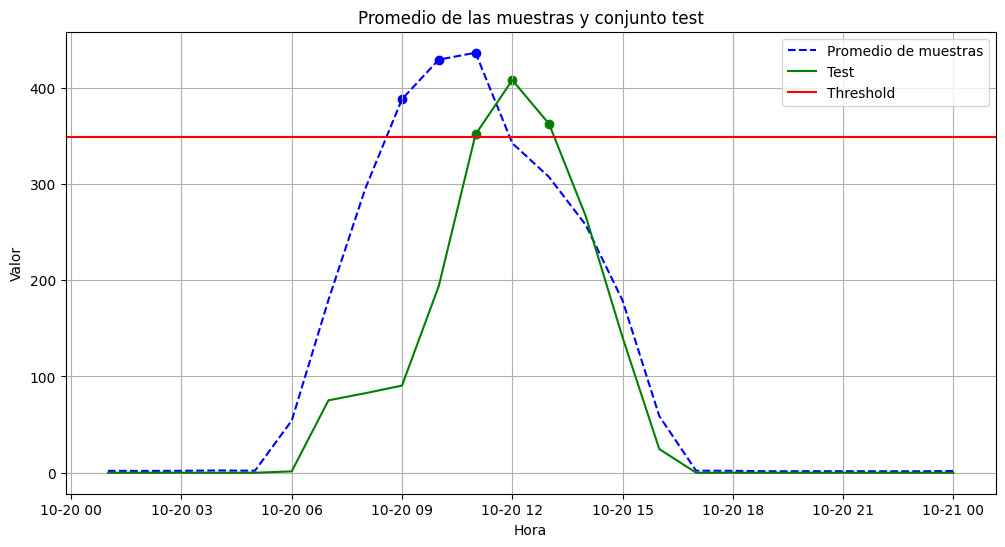

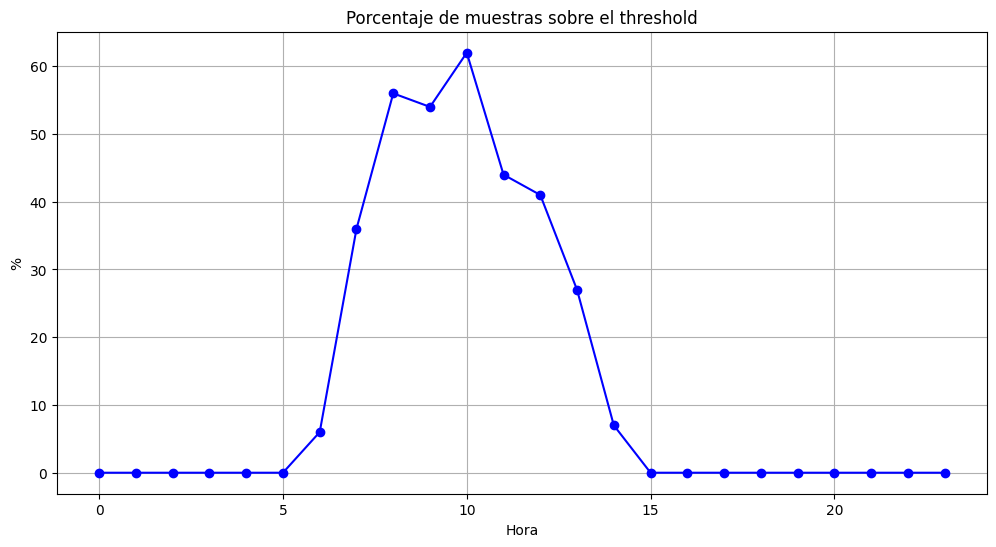

In [78]:
p90 = np.percentile(train, 90)
print(f"Max: {train.max()}\nMin: {train.min()}\np90: {p90}")

plot_with_threshold(train, p90)
plot_samples_with_threshold(samples, p90)
plot_POT(samples, test, p90)
plot_porcentaje_POT(samples, p90)


## P95

Max: 509.04998779296875
Min: 0.0
p95: 393.5600036621093


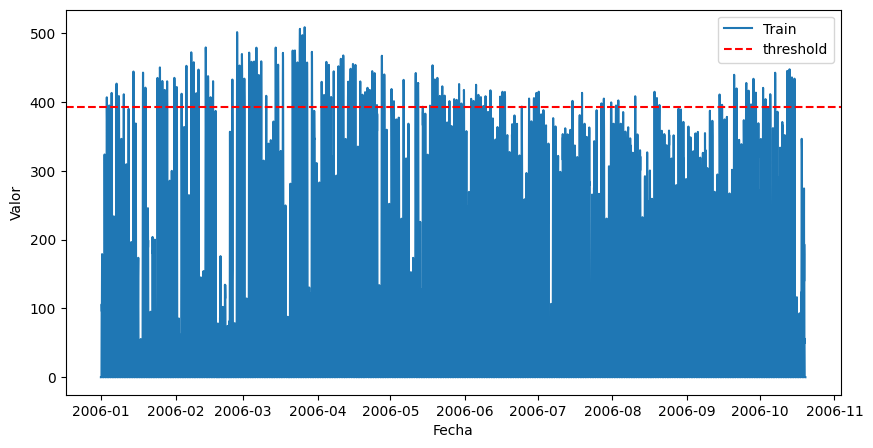

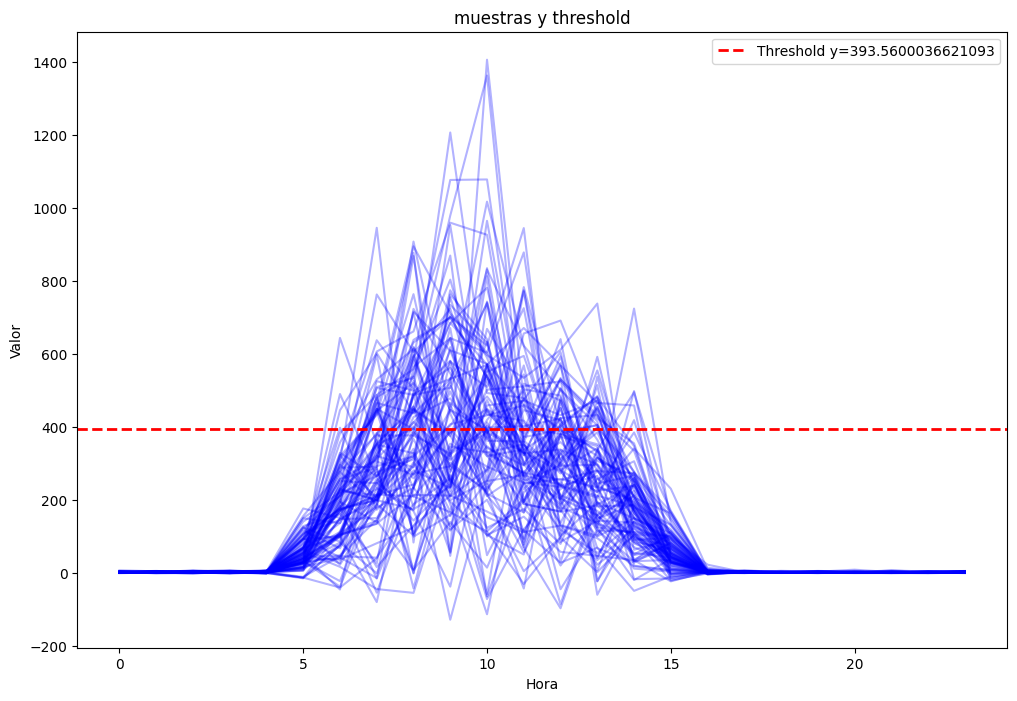

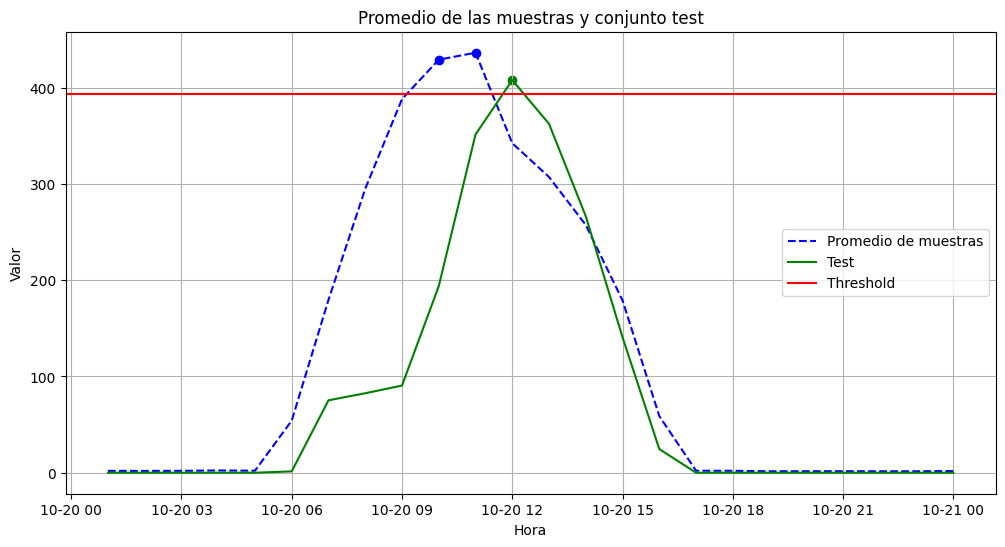

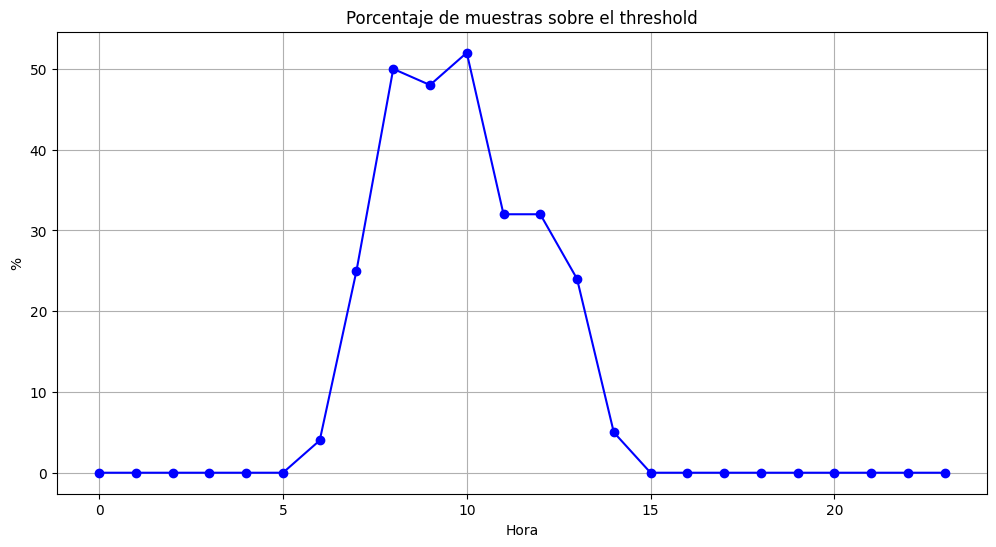

In [79]:
p95 = np.percentile(train, 95)
print(f"Max: {train.max()}\nMin: {train.min()}\np95: {p95}")

plot_with_threshold(train, p95)
plot_samples_with_threshold(samples, p95)
plot_POT(samples, test, p95)
plot_porcentaje_POT(samples, p95)


## P70

Max: 509.04998779296875
Min: 0.0
p70: 139.46000061035124


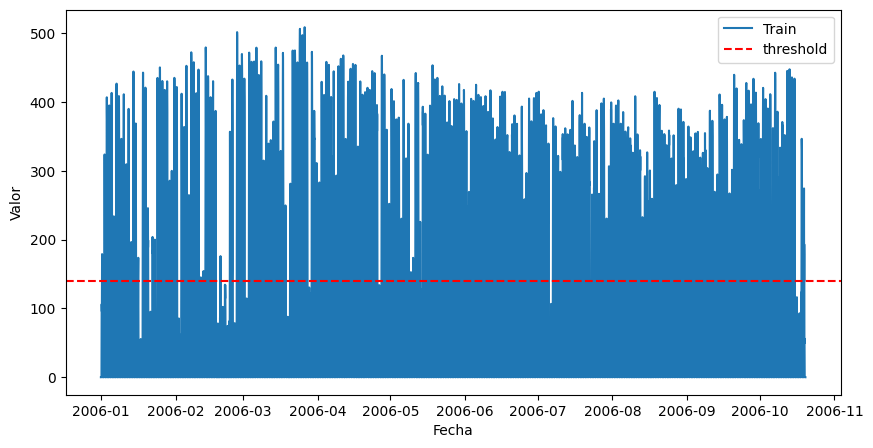

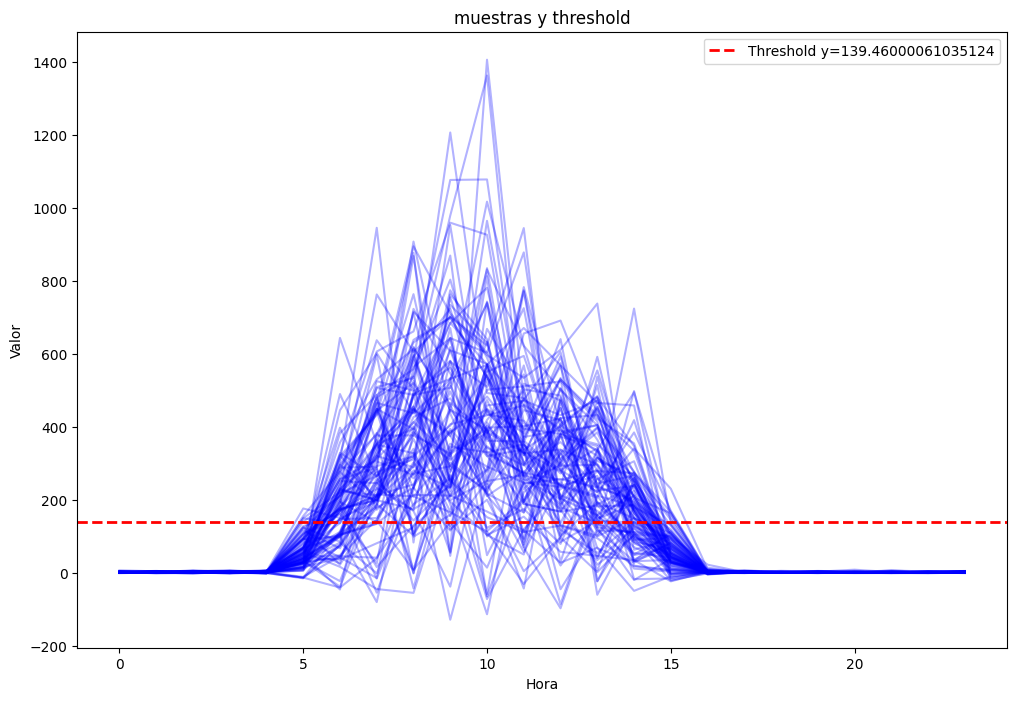

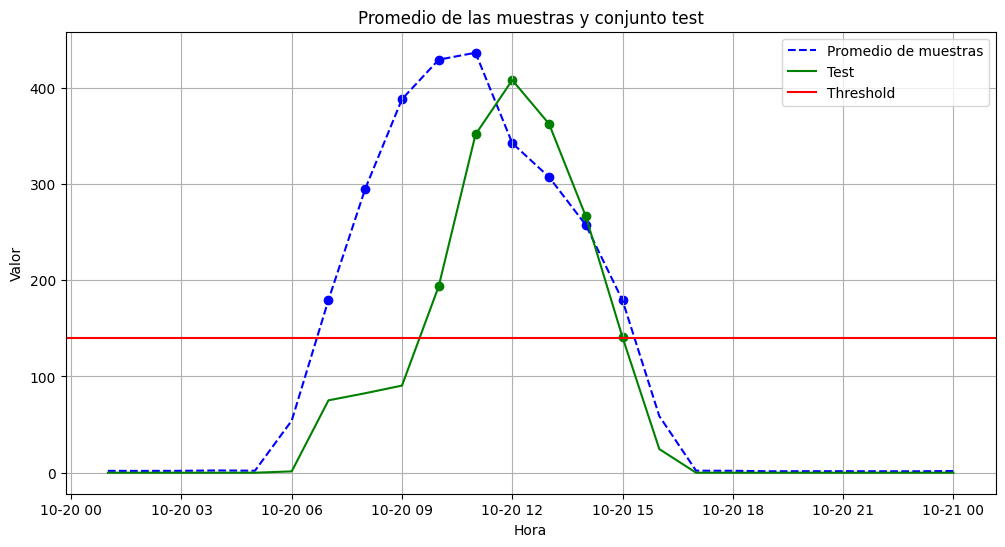

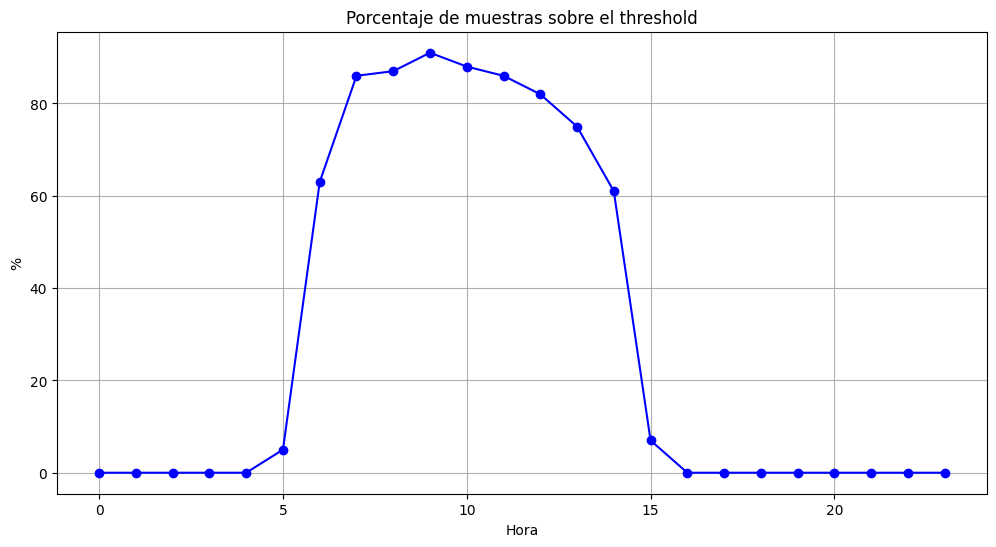

In [82]:
p70 = np.percentile(train, 70)
print(f"Max: {train.max()}\nMin: {train.min()}\np70: {p70}")

plot_with_threshold(train, p70)
plot_samples_with_threshold(samples, p70)
plot_POT(samples, test, p70)
plot_porcentaje_POT(samples, p70)


## P65

Max: 509.04998779296875
Min: 0.0
P65: 89.08999938964836


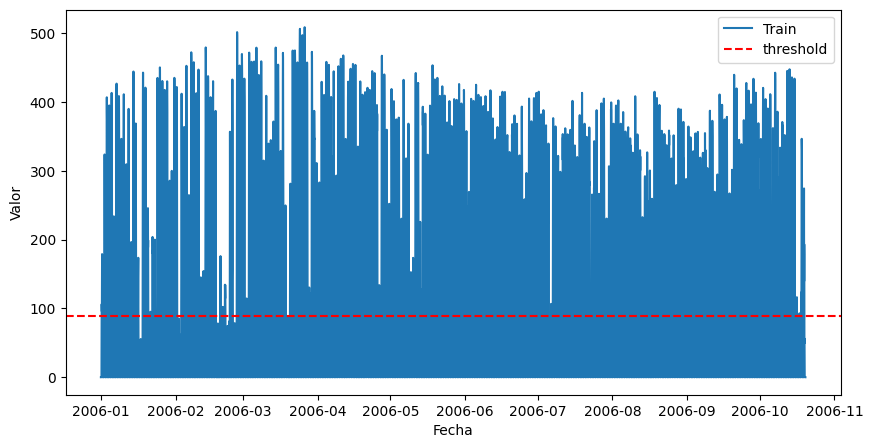

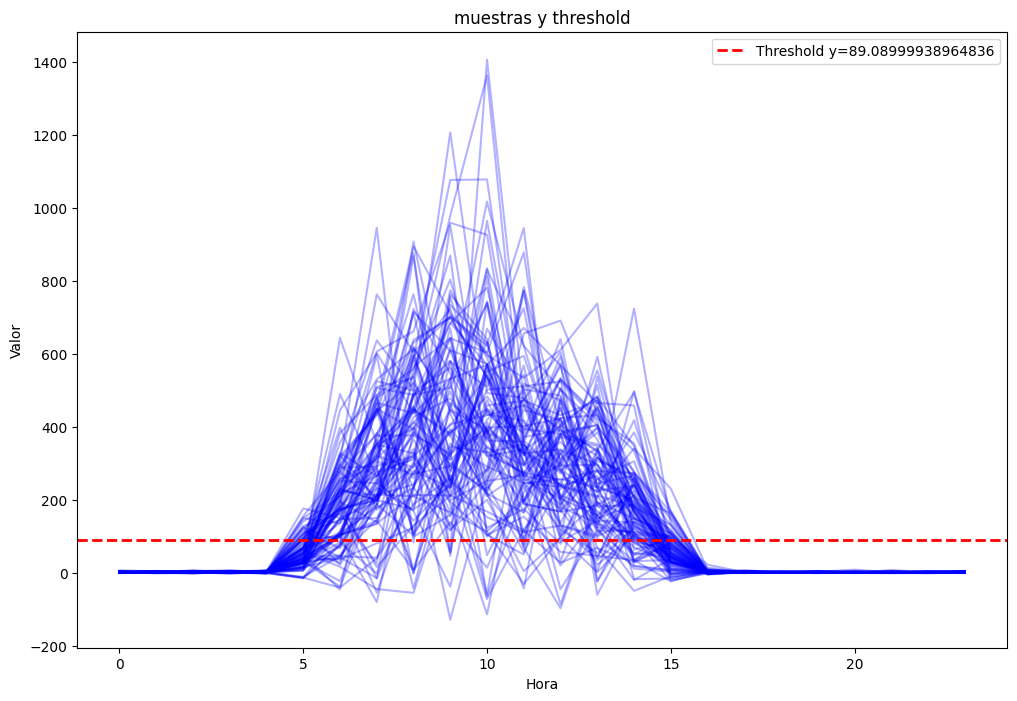

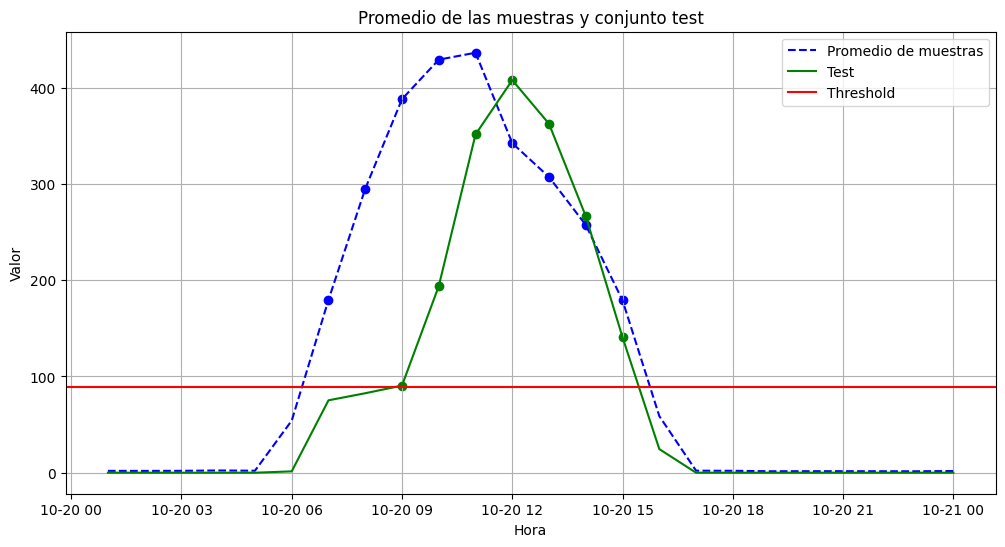

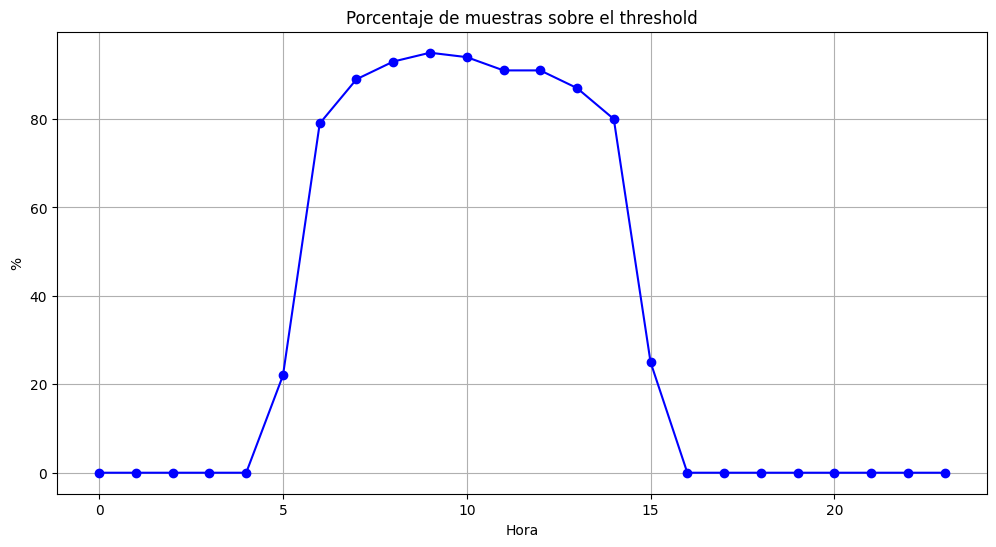

In [83]:
P65 = np.percentile(train, 65)
print(f"Max: {train.max()}\nMin: {train.min()}\nP65: {P65}")

plot_with_threshold(train, P65)
plot_samples_with_threshold(samples, P65)
plot_POT(samples, test, P65)
plot_porcentaje_POT(samples, P65)

# Predicción a 24 horas

In [12]:
import matplotlib.pyplot as plt

def plot_samples_with_threshold(data, threshold):

    plt.figure(figsize=(12, 8))

    # Plotear todas las muestras
    for i in range(data.shape[0]):
        plt.plot(data[i], color='blue', alpha=0.3)

    # Agregar la línea recta de umbral
    plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Umbral (y={threshold})')

    # Configurar etiquetas y leyenda
    plt.xlabel('Hora')
    plt.ylabel('Valor')
    plt.title('Comparación de muestras de 24 horas con línea recta')
    plt.legend()
    
    # Mostrar el gráfico
    plt.show()

def rango_iqr(serie, k, return_thresholds = False): # tipicamente k = 1.5, 3
    # rango intercuantilico
    q25, q75 = np.percentile(serie, 25), np.percentile(serie, 75)
    iqr = q75 - q25
    # Linea de corte.
    cut_off = iqr * k
    #lower, upper = q25 - cut_off, q75 + cut_off
    upper = q75 + cut_off

    # Plotear la serie de tiempo
    plt.figure(figsize=(10, 5))
    plt.plot(serie, label='Serie')

    # Agregar una línea recta al gráfico
    # Por ejemplo, una línea horizontal en y=3
    plt.axhline(y=upper, color='r', linestyle='--', label='threshold')

    # Configurar etiquetas y leyenda
    plt.xlabel('Fecha')
    plt.ylabel('Valor')
    plt.legend()

    # Mostrar el gráfico
    plt.show()

    return upper

def plot_exceedances(data, threshold):
    exceedances = np.sum(data > threshold, axis=0)

    # Configuración del gráfico
    plt.figure(figsize=(10, 6))

    # Graficar las excedencias
    plt.bar(range(24), exceedances, color='blue')

    # Configurar etiquetas y leyenda
    plt.xlabel('Hora')
    plt.ylabel('Cantidad de muestras que superan el umbral')
    plt.title('Cantidad de muestras que superan el umbral por hora')
    plt.xticks(range(24))  # Etiquetas del eje x para cada hora

    # Mostrar el gráfico
    plt.show()


In [13]:
#trabajando con la primera serie

prediction_length = predictor_mod.prediction_length
lead_time = predictor_mod.lead_time
freq = predictor_mod.freq

muestras = forecasts_mod[0].samples
samples = muestras[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


train = targets[0][:-2 * prediction_length ][1] #Sin las ultimas 48 horas de test.
test = targets[0][-prediction_length:][1] # SoLO ULTIMAS 24

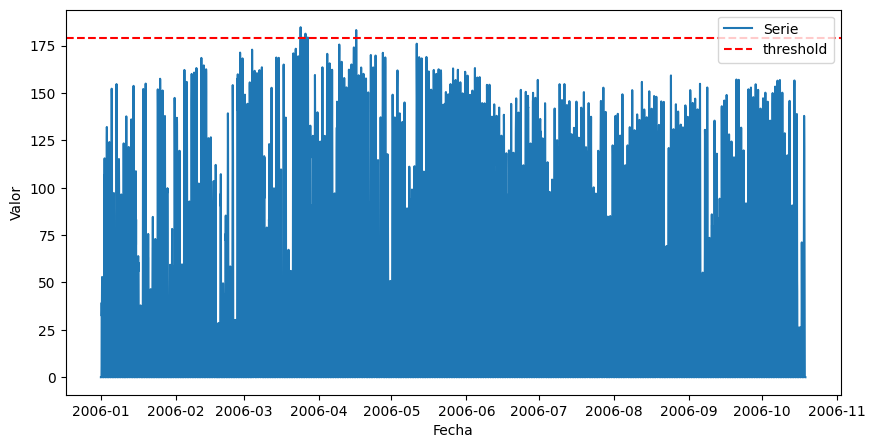

In [15]:
upper = rango_iqr(train,1.4) # Threshold.

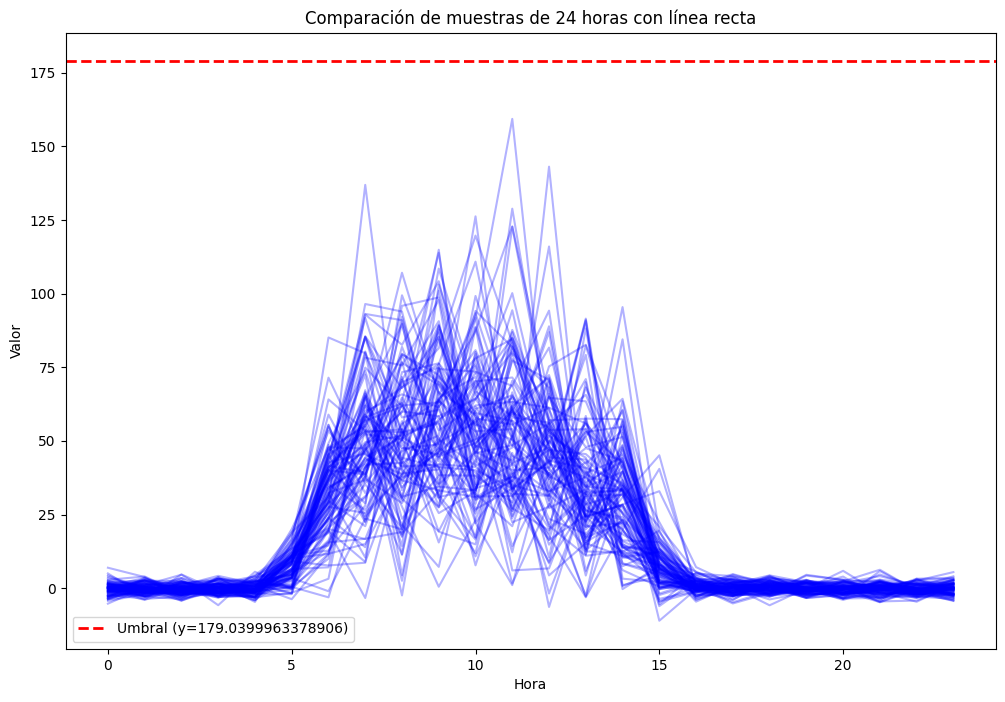

In [16]:
plot_samples_with_threshold(samples, upper)

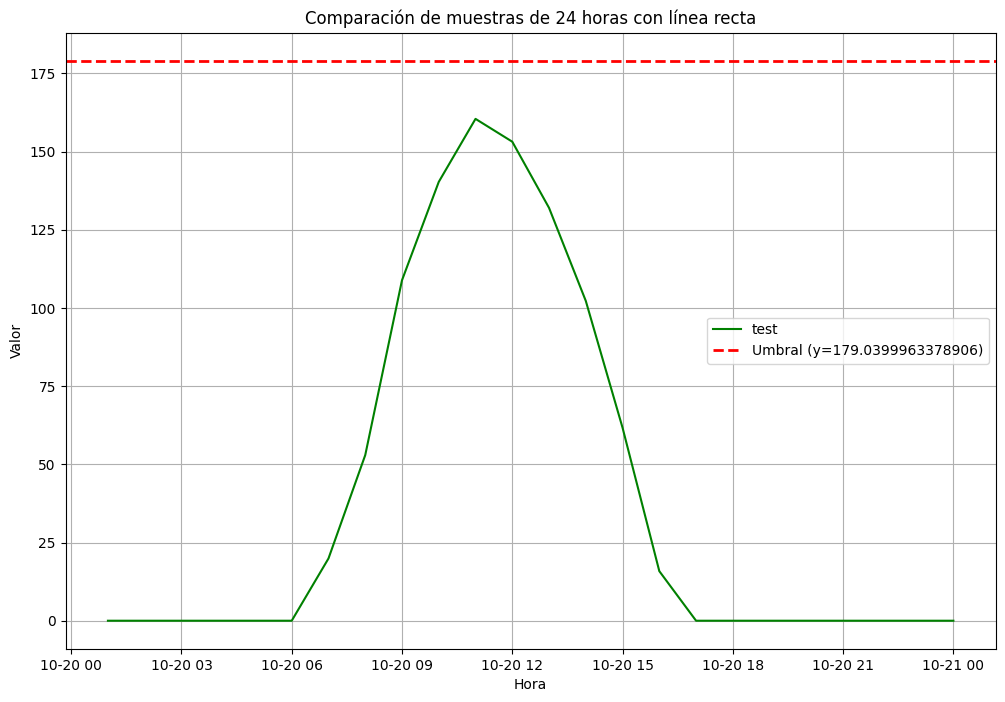

In [17]:

plt.figure(figsize=(12, 8))

# Plotear todas las muestras
plt.plot(test, color = 'green', label ='test')

# Agregar la línea recta de umbral
plt.axhline(y=upper, color='r', linestyle='--', linewidth=2, label=f'Umbral (y={upper})')

# Configurar etiquetas y leyenda
plt.xlabel('Hora')
plt.ylabel('Valor')
plt.title('Comparación de muestras de 24 horas con línea recta')
plt.legend()
plt.grid(True)
# Mostrar el gráfico
plt.show()

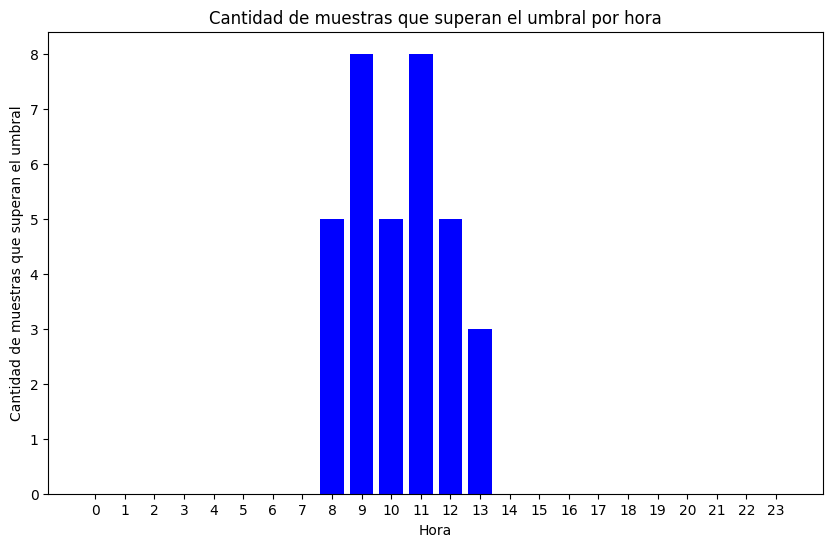

In [62]:
plot_exceedances(samples, upper)


# IMPORTANCE SAMPLING EN UNA SERIE TEMPORAL

In [23]:
#trabajando con la primera serie

prediction_length = predictor_mod.prediction_length
lead_time = predictor_mod.lead_time
freq = predictor_mod.freq

muestras = forecasts_mod[0].samples
samples = muestras[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


log_probs = forecasts_mod[0].log_prob
log_probs =log_probs[:,:,1]
probs = np.exp(log_probs)

log_probs_a = forecasts_mod[0].log_prob_a
log_probs_a =log_probs_a[:,:,1]
probs_a = np.exp(log_probs_a)

In [24]:
print(f"Validación para una característica de la serie multivariada (son 137):\nProbs shape:{probs.shape}\nProbs ax shape: {probs_a.shape}\nSamples shape:{samples.shape}\nTarget shape:{target.shape}")

Validación para una característica de la serie multivariada (son 137):
Probs shape:(100, 24)
Probs ax shape: (100, 24)
Samples shape:(100, 24)
Target shape:(48,)


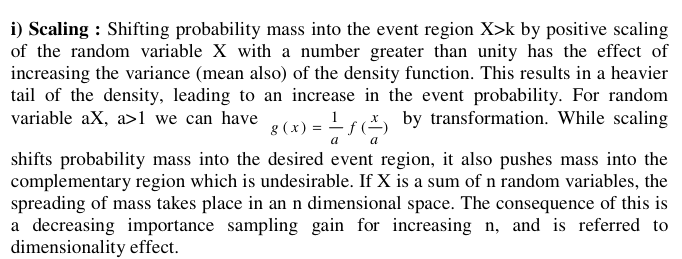

In [25]:
def peak_over_threshold(alpha, values):
    return (values >= alpha) #sumamos en la dimensión de las muestras
    

In [31]:
def IS(probs, scaled_prob, scale, alpha, samples):
    '''
    Realiza el Importance sampling.
    inputs:
    probs: probabilidades de cada muestra y cada instante de tiempo (100,24).
    scale: escala para la proposal distribution q(x), la que se utiliza en el importance sampling.
    alpha: cota que define un valor extremo.
    samples: Muestras (100,24).
    
    '''

    weights = scale*probs/scaled_prob # shape (100,24). Pesos para el importance sampling

    f = peak_over_threshold(alpha, samples*scale) #100,24

    return (f*weights).mean(axis=0) #devolvemos el promedio de las muestras.



In [32]:
def IMC(alpha, samples):
    f = peak_over_threshold(alpha, samples)
    return f.mean(axis=0)

In [33]:
IMC(1, samples)

array([0.02, 0.06, 0.02, 0.02, 0.03, 0.75, 0.97, 0.99, 1.  , 1.  , 0.99,
       0.98, 0.99, 1.  , 0.99, 0.93, 0.46, 0.12, 0.08, 0.04, 0.04, 0.08,
       0.08, 0.05])

In [34]:
IS(probs, probs_a, 0.8, 1, samples)

array([1.6895373e-04, 0.0000000e+00, 2.3470535e-04, 4.0631945e-04,
       1.6004759e-03, 6.5533447e-01, 2.6975391e+00, 3.8842819e+00,
       4.8329101e+00, 4.6373782e+00, 5.7453575e+00, 5.5537415e+00,
       5.0208879e+00, 5.0208879e+00, 3.7373109e+00, 1.9627507e+00,
       2.1300207e-01, 1.0311685e-02, 1.9199493e-03, 7.4589206e-04,
       6.9717580e-04, 2.7709091e-03, 1.1219627e-03, 1.5296616e-03],
      dtype=float32)

# OLD

In [40]:
def rango_iqr(s, k, return_thresholds = False):
  # rango intercuantilico
  q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
  iqr = q75 - q25
  # Linea de corte.
  cut_off = iqr * k
  lower, upper = q25 - cut_off, q75 + cut_off
  print(f"Lower bound: {lower}\nUpper bound: {upper}")
  if return_thresholds:
      return lower, upper
  else: # identificar valores extremos
      return [True if x < lower or x > upper else False for x in s]
  
targets_df = pd.DataFrame()
targets_df["Target"] = target
targets_df.index = target_index

def graficar_extreme_values(k):

    targets_df["Extreme value"] = targets_df[["Target"]].apply(rango_iqr, k=k)
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

    col = np.where(targets_df['Extreme value'] == True, 'blue', 'silver')
    ax.scatter(targets_df.index, targets_df['Target'], c=col)
    ax.set_title('Extreme values para todos los años', size=18)
    ax.set_ylabel("Generacion [MW]")
    ax.set_xlabel('Fecha')

    plt.tight_layout()
    plt.show()

Lower bound: -118.72500228881836
Upper bound: 158.3000030517578


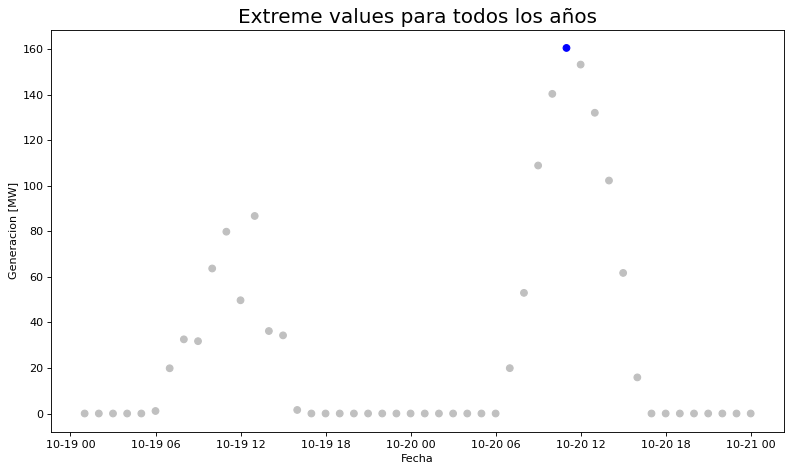

In [43]:
graficar_extreme_values(3)

In [44]:
def indicatriz(arr, alpha):
    if np.any(arr > alpha):
        return 1
    else:
        return 0
    
def MC(f, samples, alpha):
    sum = 0
    for i in range(samples.shape[0]):
        function_value = f(samples[i,:], alpha)
        sum+=function_value
    
    return (sum/samples.shape[0])


In [45]:
MC(indicatriz, samples, alpha = 158.3000030517578)

0.0

# Pruebas distribución


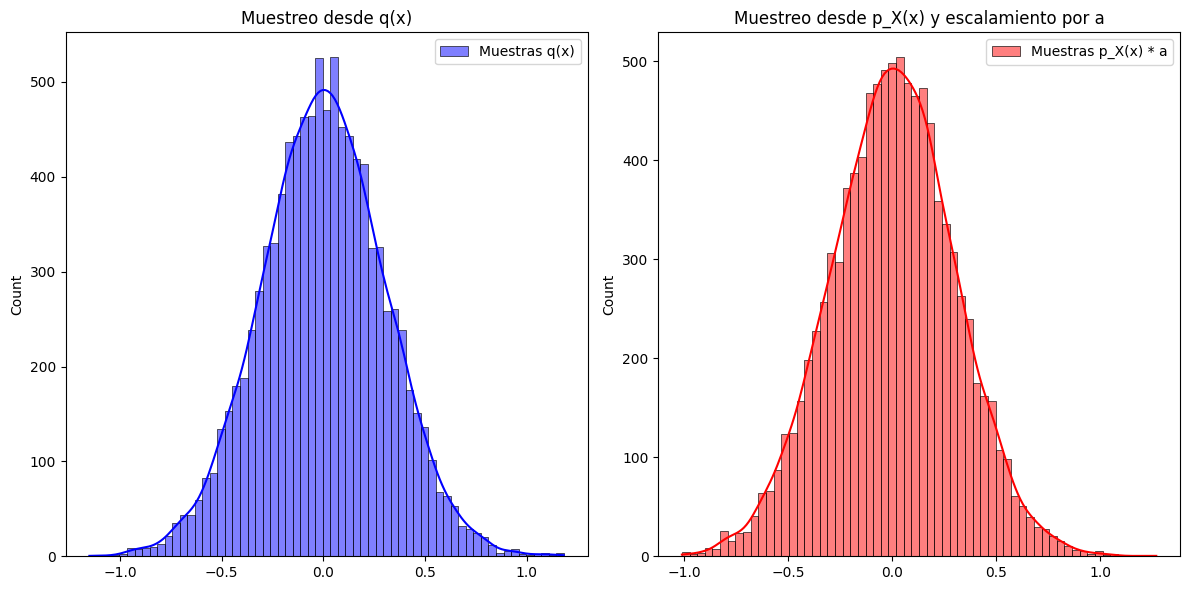

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Parámetros
mu_X = 0
sigma_X = 1
a = 0.3

# Distribución objetivo p_X(x)
p_X = stats.norm(mu_X, sigma_X)

# Distribución de propuesta q(x)
mu_q = mu_X * a
sigma_q = sigma_X * a
q = stats.norm(mu_q, sigma_q)

# Número de muestras
N = 10000

# Muestreo directo desde q(x)
samples_q = q.rvs(N)

# Muestreo desde p_X(x) y escalamiento por a
samples_p_scaled = p_X.rvs(N) * a

# Histogramas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Muestreo desde q(x)')
sns.histplot(samples_q, kde=True, color='blue', label='Muestras q(x)')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Muestreo desde p_X(x) y escalamiento por a')
sns.histplot(samples_p_scaled, kde=True, color='red', label='Muestras p_X(x) * a')
plt.legend()

plt.tight_layout()
plt.show()


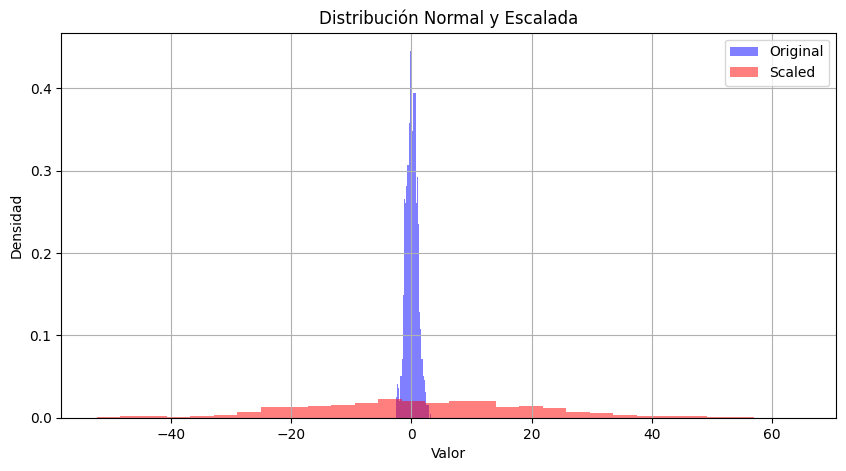

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar muestras de una distribución normal con media 0 y desviación estándar 1
mu = 0
sigma = 1
sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

# Graficar el histograma de las muestras originales
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=30, density=True, alpha=0.5, color='b', label='Original')

# Escalar las muestras
scaled_samples = samples * 20  # Escalar por un factor de 2

# Graficar el histograma de las muestras escaladas
plt.hist(scaled_samples, bins=30, density=True, alpha=0.5, color='r', label='Scaled')

plt.title('Distribución Normal y Escalada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()